# Линейная регрессия

In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import random
import os
from IPython.display import display, Image

## Датасет

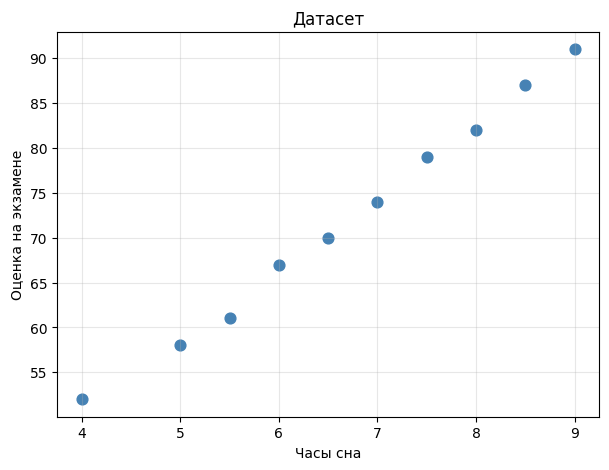

In [2]:
# Количество часов сна → оценка на экзамене
feature = [4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9]
target  = [52, 58, 61, 67, 70, 74, 79, 82, 87, 91]

plt.figure(figsize=(7, 5))
plt.scatter(feature, target, color='steelblue', s=60)
plt.xlabel('Часы сна')
plt.ylabel('Оценка на экзамене')
plt.title('Датасет')
plt.grid(True, alpha=0.3)
plt.show()

## Вспомогательные функции

In [3]:
def save_gif(history, path='assets/linear_regression.gif', interval=300, step=1):
    """
    Сохраняет анимацию движения прямой в GIF и выводит её в ноутбуке.

    history  — список пар (w, b), по одной на итерацию обучения.
    step     — брать каждый N-й кадр (step=10 → в 10 раз меньше кадров).
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    frames = history[::step]

    fig, ax = plt.subplots(figsize=(7, 5))

    def draw_frame(i):
        w, b = frames[i]
        ax.clear()
        ax.scatter(feature, target, color='steelblue', s=60, label='Данные')
        x_line = [min(feature), max(feature)]
        y_line = [w * x + b for x in x_line]
        ax.plot(x_line, y_line, color='tomato', linewidth=2, label=f'y = {w:.2f}x + {b:.2f}')
        ax.set_xlabel('Часы сна')
        ax.set_ylabel('Оценка')
        ax.set_title(f'Итерация {i * step + 1}/{len(history)}')
        ax.set_ylim(40, 100)
        ax.legend()
        ax.grid(True, alpha=0.3)

    anim = animation.FuncAnimation(fig, draw_frame, frames=len(frames), interval=interval)
    anim.save(path, writer='pillow')
    plt.close(fig)
    print(f'GIF сохранён: {path}  ({len(frames)} кадров из {len(history)})')
    display(Image(filename=path))

## Метод 1: Простой подход

Идея простого подхода в том, чтобы на каждой эпохе двигать линию в зависимости от одного из четырёх исходов. Линия, в случае когда у нас один признак, двигается через `b` (смещение) и `w` (уровень наклона). В формуле `y = w * x + b`, `w` — вес признака, `b` — базовое смещение.

При обучении задача алгоритма — подобрать `w` и `b` так, чтобы суммарное расстояние от каждой точки до прямой было минимальным.

**Возможные исходы:**
1. Точка над прямой и справа от Y — вращаем против часовой стрелки и смещаем вверх.
2. Точка над прямой и слева от Y — вращаем по часовой стрелке и смещаем вверх.
3. Точка под прямой и справа от Y — вращаем по часовой стрелке и смещаем вниз.
4. Точка под прямой и слева от Y — вращаем против часовой стрелки и смещаем вниз.

![Четыре сценария. В каждом из них мы должны повернуть и переместить прямую по-своему, чтобы приблизить её к соответствующей точке.](./assets/simple_approach_scenarios.png)

Затем на каждой эпохе выбираем случайную точку, определяем один из четырёх исходов и обновляем `w` и `b`.

In [4]:
random.seed(42)
epochs = 1000

w, b = random.randint(0, 10) / 10, random.randint(0, 10) / 10
eta_w, eta_b = random.randint(1, 10) / 10, random.randint(1, 10) / 10
print(f"{w=}, {b=}")

params_history = []
model = lambda x, w, b: x * w + b

for epoch in range(epochs):
    if epoch % 100 == 0:
        predicts = [model(x, w, b) for x in feature]
        sum_error = sum(abs(fact - pred) for fact, pred in zip(target, predicts))
        print(f"{sum_error=:.2f} {w=:.2f} {b=:.2f}")

    params_history.append((w, b))

    random_dot_index = random.randint(0, len(target) - 1)
    epoch_target  = target[random_dot_index]
    epoch_feature = feature[random_dot_index]
    predict = model(epoch_feature, w, b)

    dot_upper_line  = epoch_target > predict
    dot_left_from_y = epoch_feature < 0

    # Сценарий 1. Точка над прямой, справа от Y — против часовой, вверх
    if dot_upper_line and not dot_left_from_y:
        b += eta_b; w += eta_w
    # Сценарий 2. Точка над прямой, слева от Y — по часовой, вверх
    elif dot_upper_line and dot_left_from_y:
        b += eta_b; w -= eta_w
    # Сценарий 3. Точка под прямой, справа от Y — по часовой, вниз
    elif not dot_upper_line and not dot_left_from_y:
        b -= eta_b; w -= eta_w
    # Сценарий 4. Точка под прямой, слева от Y — против часовой, вниз
    elif not dot_upper_line and dot_left_from_y:
        b -= eta_b; w += eta_w

w=1.0, b=0.1
sum_error=653.00 w=1.00 b=0.10
sum_error=27.20 w=6.80 b=29.10
sum_error=27.40 w=6.40 b=27.10
sum_error=27.20 w=6.80 b=29.10
sum_error=19.80 w=6.60 b=28.10
sum_error=19.80 w=6.60 b=28.10
sum_error=19.80 w=6.60 b=28.10
sum_error=19.80 w=6.60 b=28.10
sum_error=19.80 w=6.60 b=28.10
sum_error=27.40 w=6.40 b=27.10


GIF сохранён: assets/linear_regression.gif  (100 кадров из 1000)


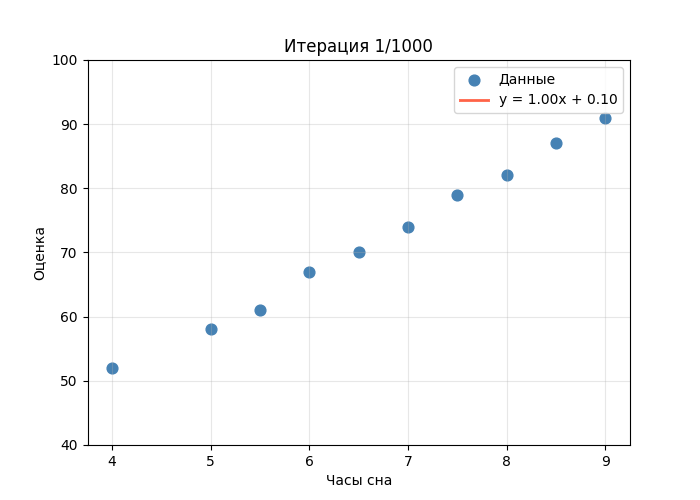

In [6]:
save_gif(params_history, interval=300, step=10)

## Метод 2: Абсолютный метод

## Метод 3: Квадратичный метод